# Thực nghiệm 2: PARAFAC2 trên dữ liệu EEG

PARAFAC2 là một dạng tổng quát của CP decomposition, cho phép một chiều của tensor có độ dài khác nhau giữa các ma trận (slices). Đặc tính này rất phù hợp với dữ liệu EEG khi mỗi subject có số lượng epochs/trials hợp lệ khác nhau sau quá trình loại bỏ nhiễu.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.data import load_eeg_raw, build_parafac2_slices, build_tensor
from src.parafac2 import parafac2_als
from src.cp_als import cp_als
from src.visualize import plot_parafac2_results, plot_parafac2_vs_cp_spatial

import mne
mne.set_log_level('WARNING')

## 1. Chuẩn bị dữ liệu cho PARAFAC2

Khác với `02_eeg_cp.ipynb` nơi chúng ta tính trung bình các trial, ở đây chúng ta giữ lại thông tin của từng trial. Mỗi subject sẽ tạo thành một slice kích thước `(n_trials, n_channels)`. Số lượng `n_trials` sẽ khác nhau tùy subject.

In [2]:
n_subjects = 5  # Dùng 5 subjects để demo nhanh PARAFAC2
subjects = list(range(1, n_subjects + 1))
runs = [4, 8, 12]

raws = load_eeg_raw(subjects, runs, verbose=False)

# Xây dựng các slice cho PARAFAC2
slices, subj_ids, info = build_parafac2_slices(
    raws, 
    l_freq=8.0, h_freq=30.0,
    tmin=-0.5, tmax=2.5,
    verbose=True
)

d:\VScode\Python\Project\csc14005-introduction-to-machine-learning\lab-3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
  Events found: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
  Using event_id: {'rest': 1, 'left': 2, 'right': 3}
Not setting metadata
90 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 90 events and 481 original time points

## 2. Chạy PARAFAC2-ALS

Chúng ta sẽ phân rã bộ slices với rank $R = 4$.

In [3]:
R = 4
print(f"Chạy PARAFAC2 với rank = {R}...")
V, weights, projections, fit_info = parafac2_als(slices, rank=R, max_iter=100, tol=1e-5, verbose=True)

Chạy PARAFAC2 với rank = 4...
PARAFAC2: K=5 slices, J=64, rank=4
  Slice sizes: [87, 87, 87, 87, 87]
  Iter   10: fit=0.68115244
  Iter   20: fit=0.69043491
  Iter   30: fit=0.72505874
  Iter   40: fit=0.72771716
  Converged at iteration 47


## 3. Trực quan hóa Kết quả

Trong kết quả của PARAFAC2:
- **V** (Shared Spatial Matrix): là không gian các kênh (channels) chung cho toàn bộ dataset.
- **Weights**: Trọng số thể hiện mức độ biểu hiện của component ở mỗi subject.
- **Projections**: Chứa thông tin về trial, đặc trưng riêng cho từng subject.

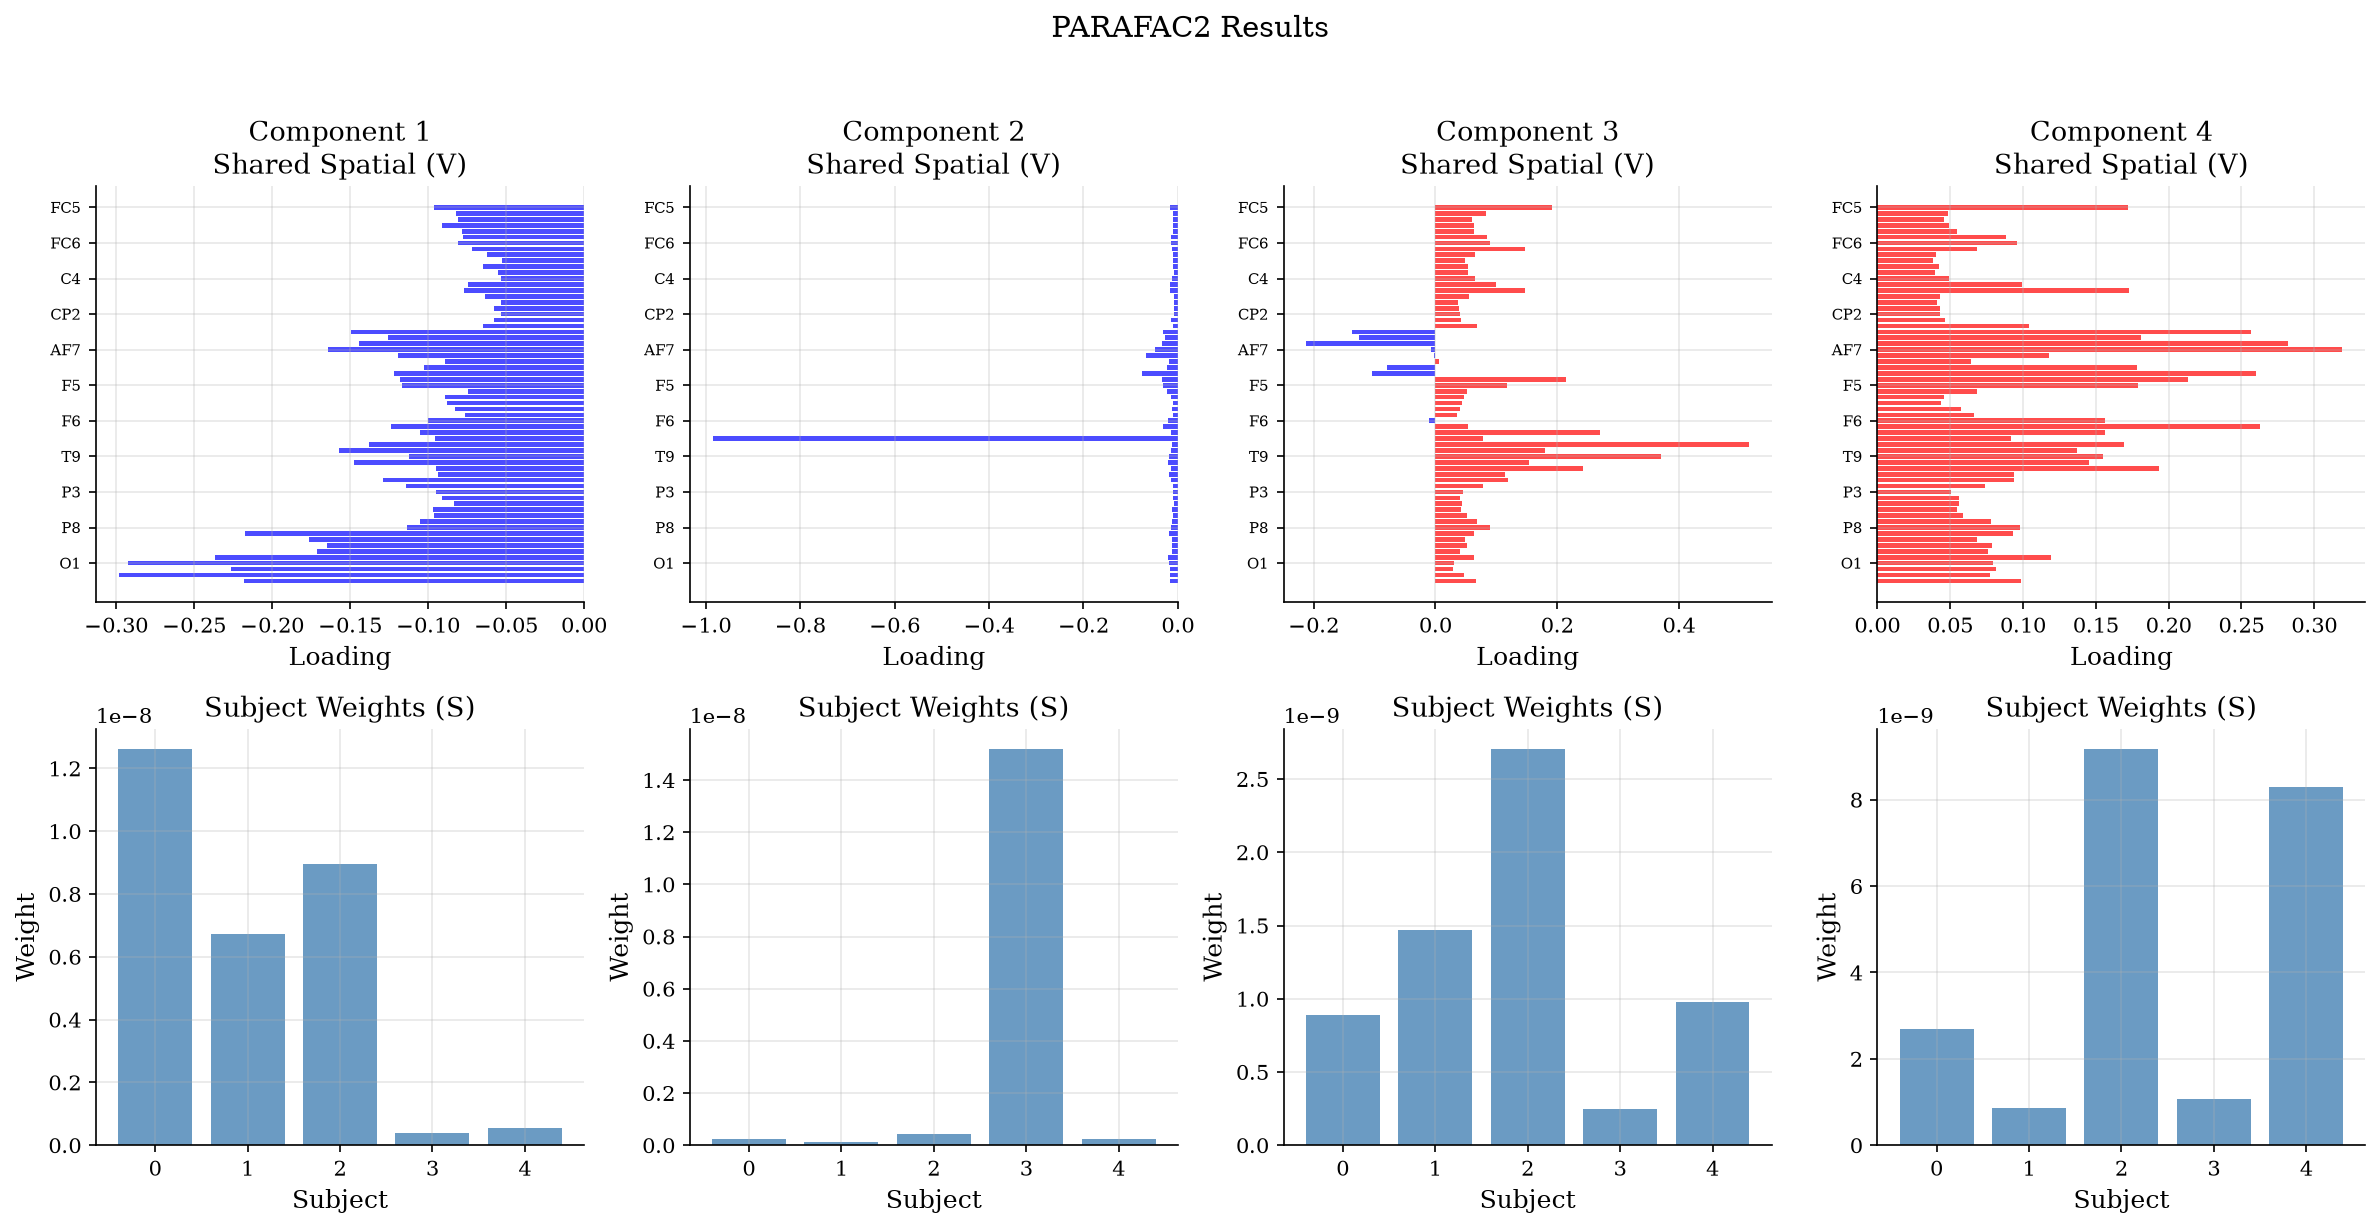

In [4]:
plot_parafac2_results(V, weights, projections, channel_names=info['channel_names'], subject_ids=subj_ids)
plt.show()

## 4. So sánh Spatial Component: CP vs PARAFAC2

Chạy CP-ALS trên dữ liệu đã trung bình hóa (như ở notebook 02) và so sánh với PARAFAC2.

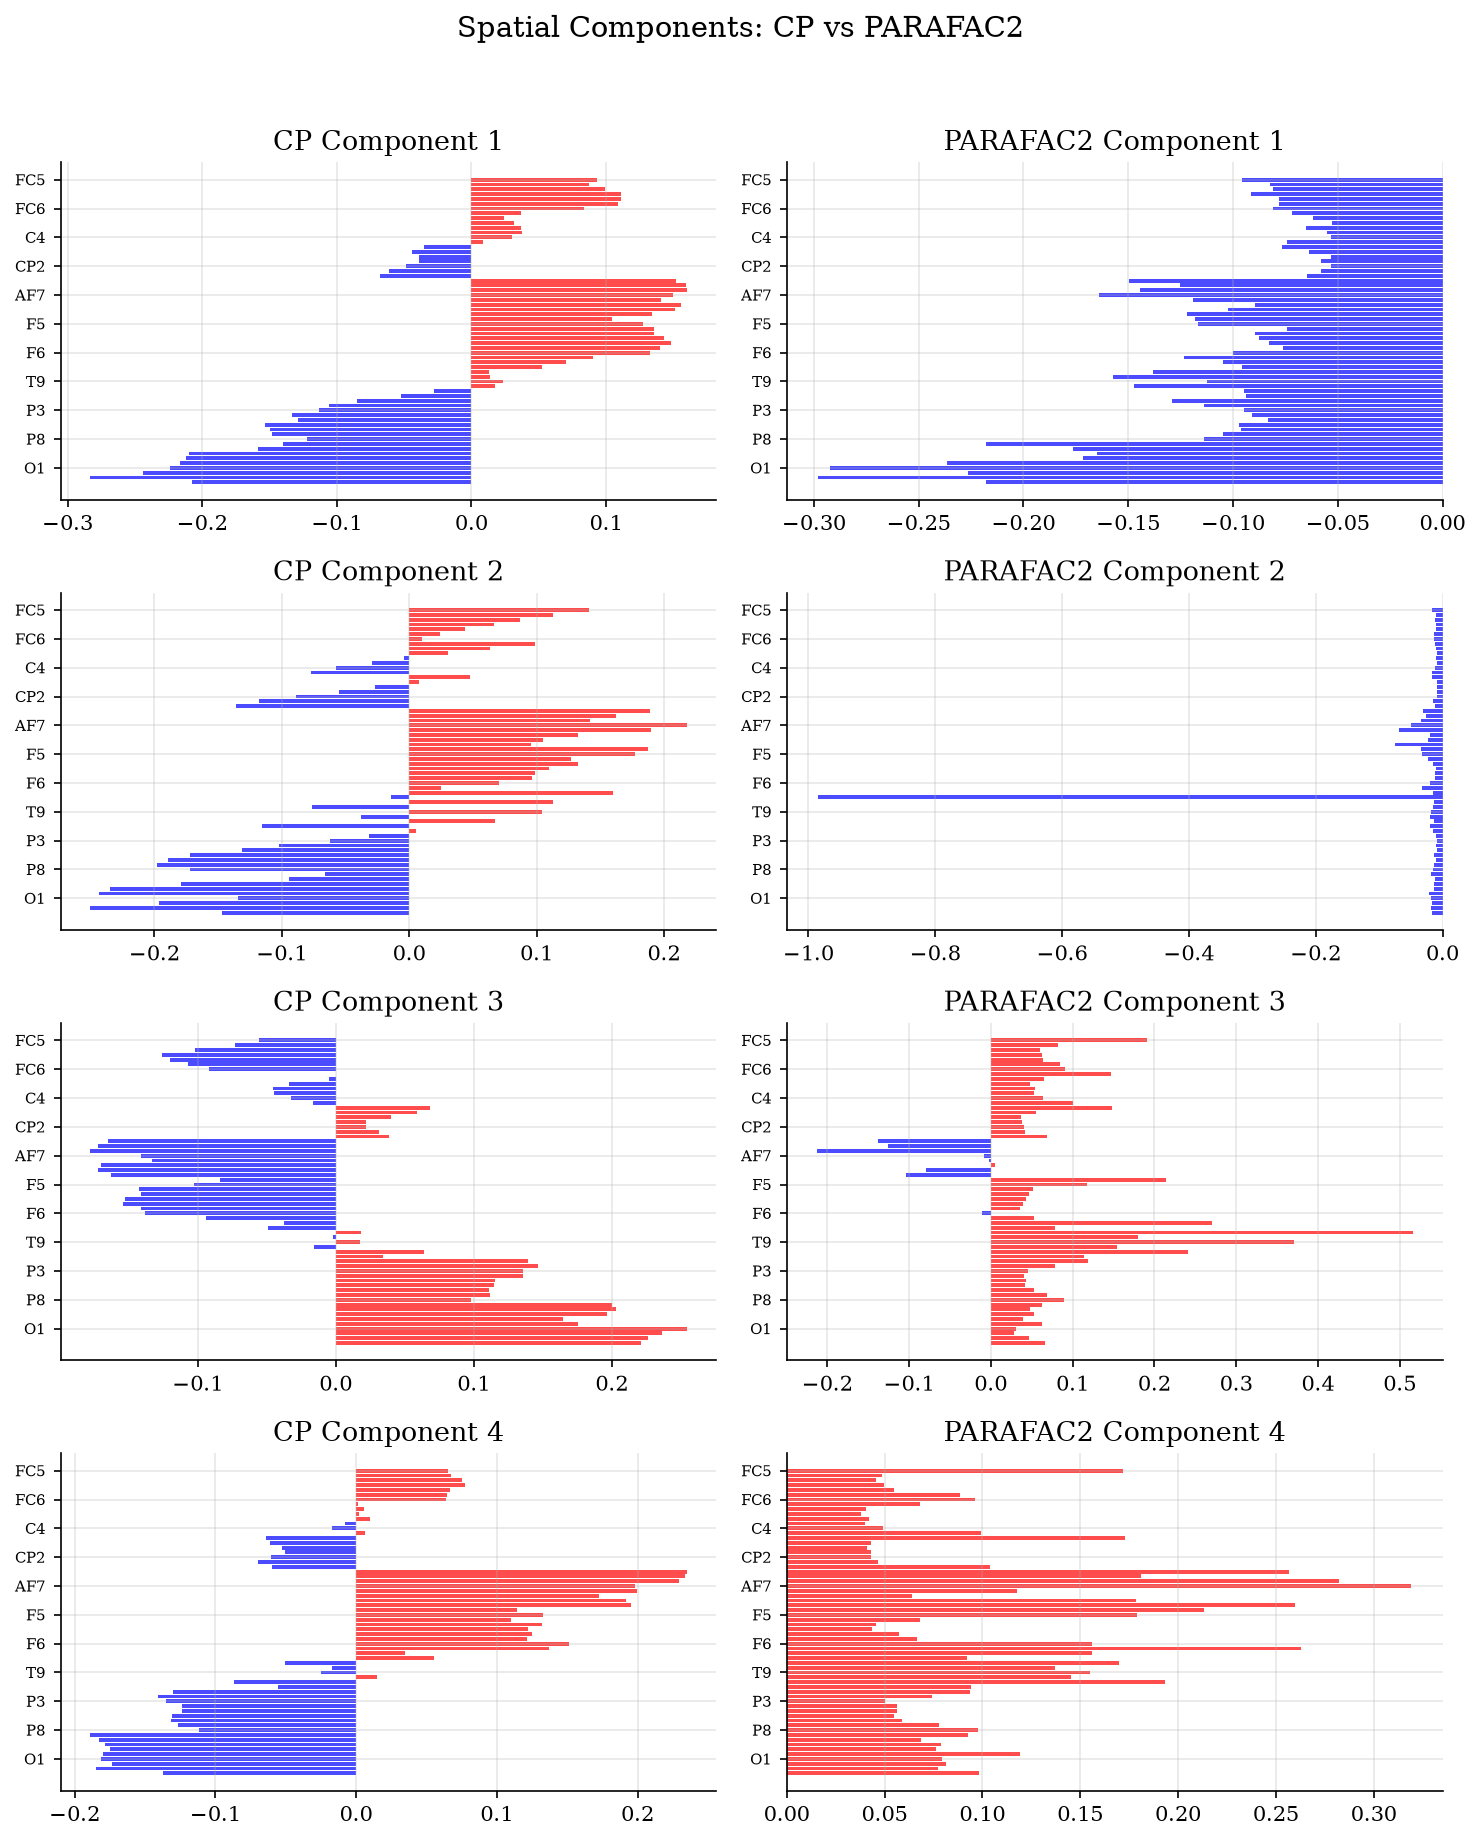

In [5]:
tensor, _, _ = build_tensor(raws, l_freq=8.0, h_freq=30.0, tmin=-0.5, tmax=2.5, average_trials=True, verbose=False)
_, f0, f1, f2 = cp_als(tensor, rank=R, max_iter=100, tol=1e-5, verbose=False)
cp_factors = [f0, f1, f2]

plot_parafac2_vs_cp_spatial(cp_factors, V, channel_names=info['channel_names'])
plt.show()